In [37]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from pathlib import Path

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, Fabelo2DCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data import HSIPixelDataset, HSIPatchDataset
from brainvision.data.io import load_all_campaigns
from brainvision.validation import get_splits
from brainvision.utils import build_run_name
from brainvision.metrics import (compute_metrics, aggregate_fold_metrics,
                                  print_metrics, print_aggregate)
from brainvision.history import plot_history_curves, load_history
from brainvision.device import get_device, print_device_info, empty_device_cache

In [38]:
device = get_device()
print_device_info(device)

  Device     : MPS
  Name       : Apple Silicon (MPS)
  Memory     : 19,070 MB total  | N/A free  | N/A used


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE EXPERIMENT HERE
# ══════════════════════════════════════════════════════════════════════════════

MODEL    = "1D-NN"      # "1D-NN" | "1D-NN-Fabelo" | "1D-CNN" | "2D-CNN" | "3D-CNN" | "SF"
LOSS_FN  = "UFL"                 # "CE" | "FL" | "DL" | "UFL"
REDUCE_PIXELS = True            # apply K-Means reduction to training set

STRATEGY = "vp_fabelo"          # "vp1" | "vp2" | "vp3" | "lopo" | "vp_fabelo"
N_FOLDS  = 5                    # used for vp3 and lopo only; vp_fabelo always uses 5 folds

In [40]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: Fabelo2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band    = SF_NEAR_BAND,
                                              dim          = SF_DIM,
                                              depth        = SF_DEPTH,
                                              heads        = SF_HEADS,
                                              dim_head     = SF_DIM_HEAD,
                                              mlp_dim      = SF_MLP_DIM,
                                              dropout      = SF_DROPOUT,
                                              emb_dropout  = SF_EMB_DROPOUT,
                                              mode         = SF_MODE),
}

In [41]:
campaigns = load_all_campaigns(PROCESSED_DIRS)

Campaigns loaded from memory cache (61 patients across 3 campaigns)


In [42]:
all_splits = get_splits(campaigns, STRATEGY)


════════════════════════════════════════════════════════════
  Training Curves — 1D-NN × UFL × vp_fabelo
════════════════════════════════════════════════════════════


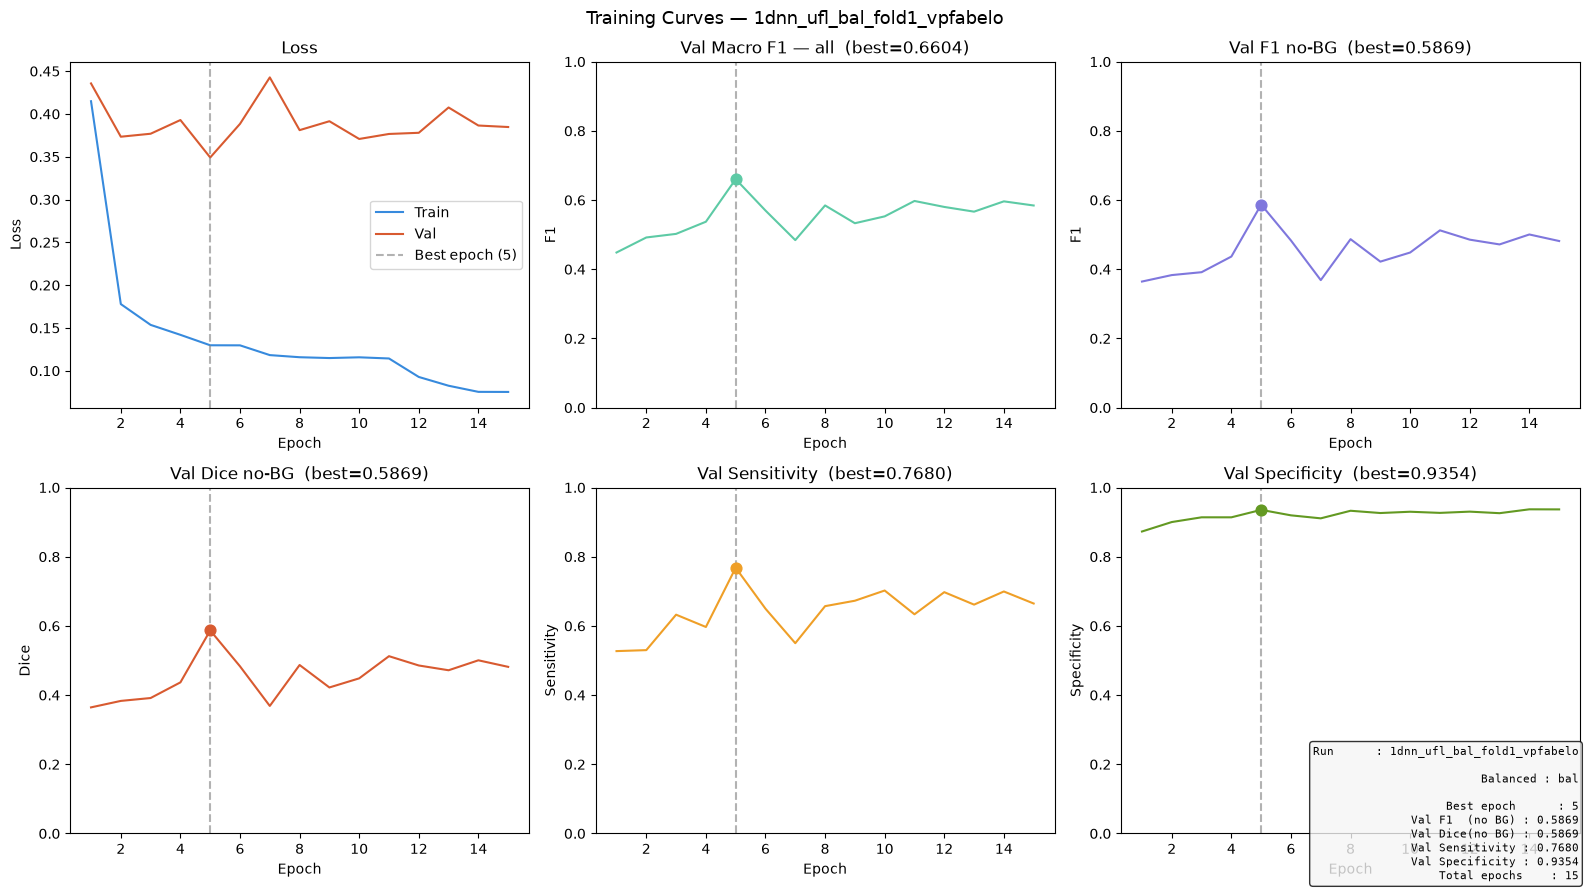

  Saved → ../results/1dnn_ufl_bal_fold1_vpfabelo_curves.png


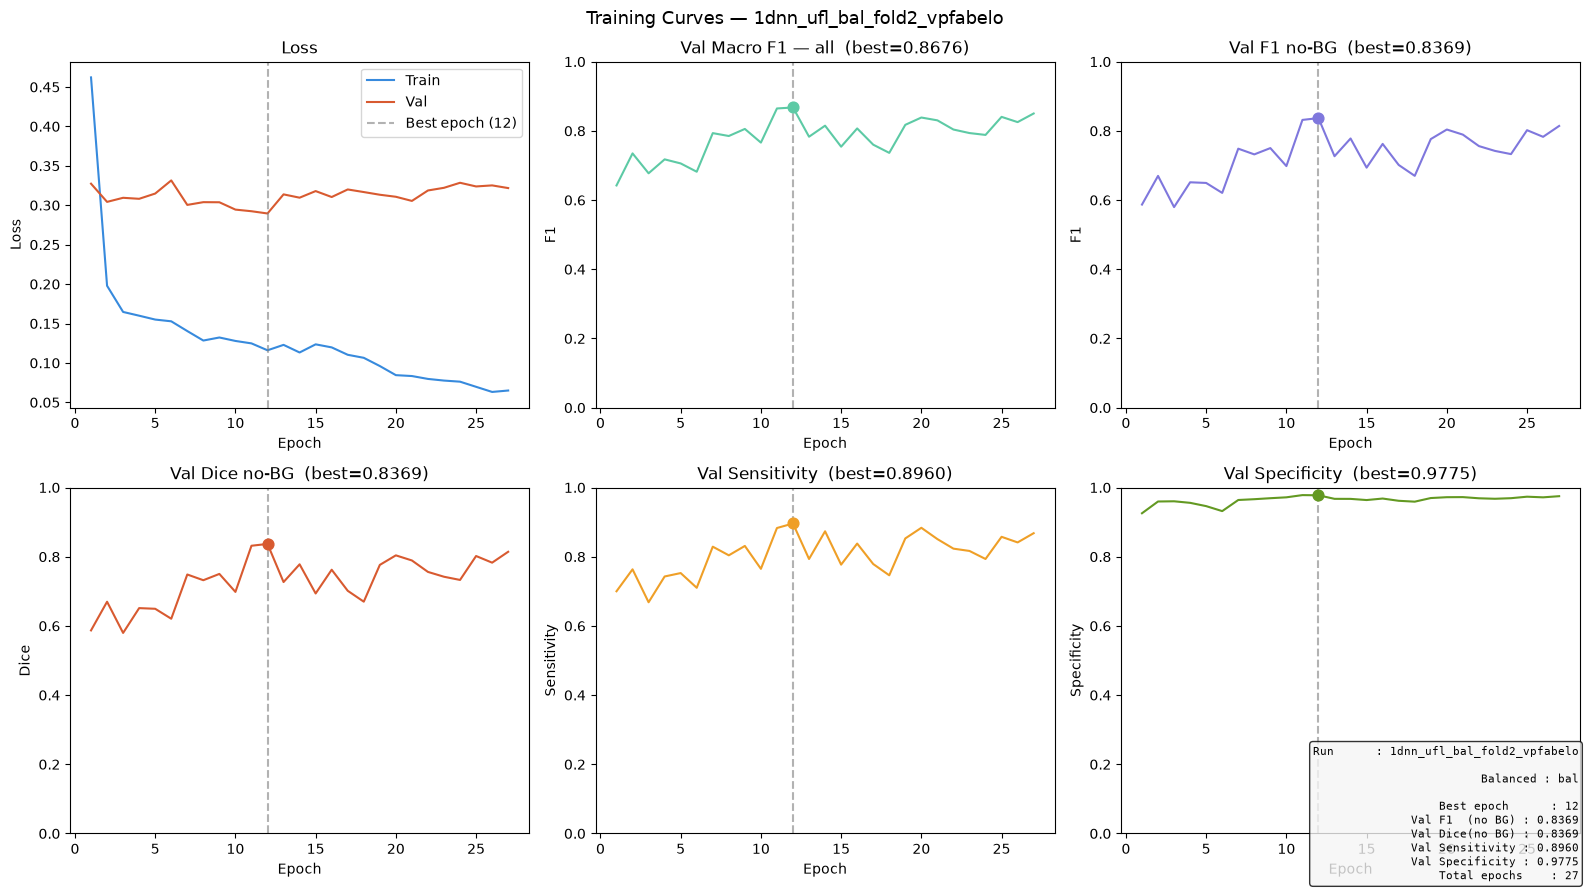

  Saved → ../results/1dnn_ufl_bal_fold2_vpfabelo_curves.png


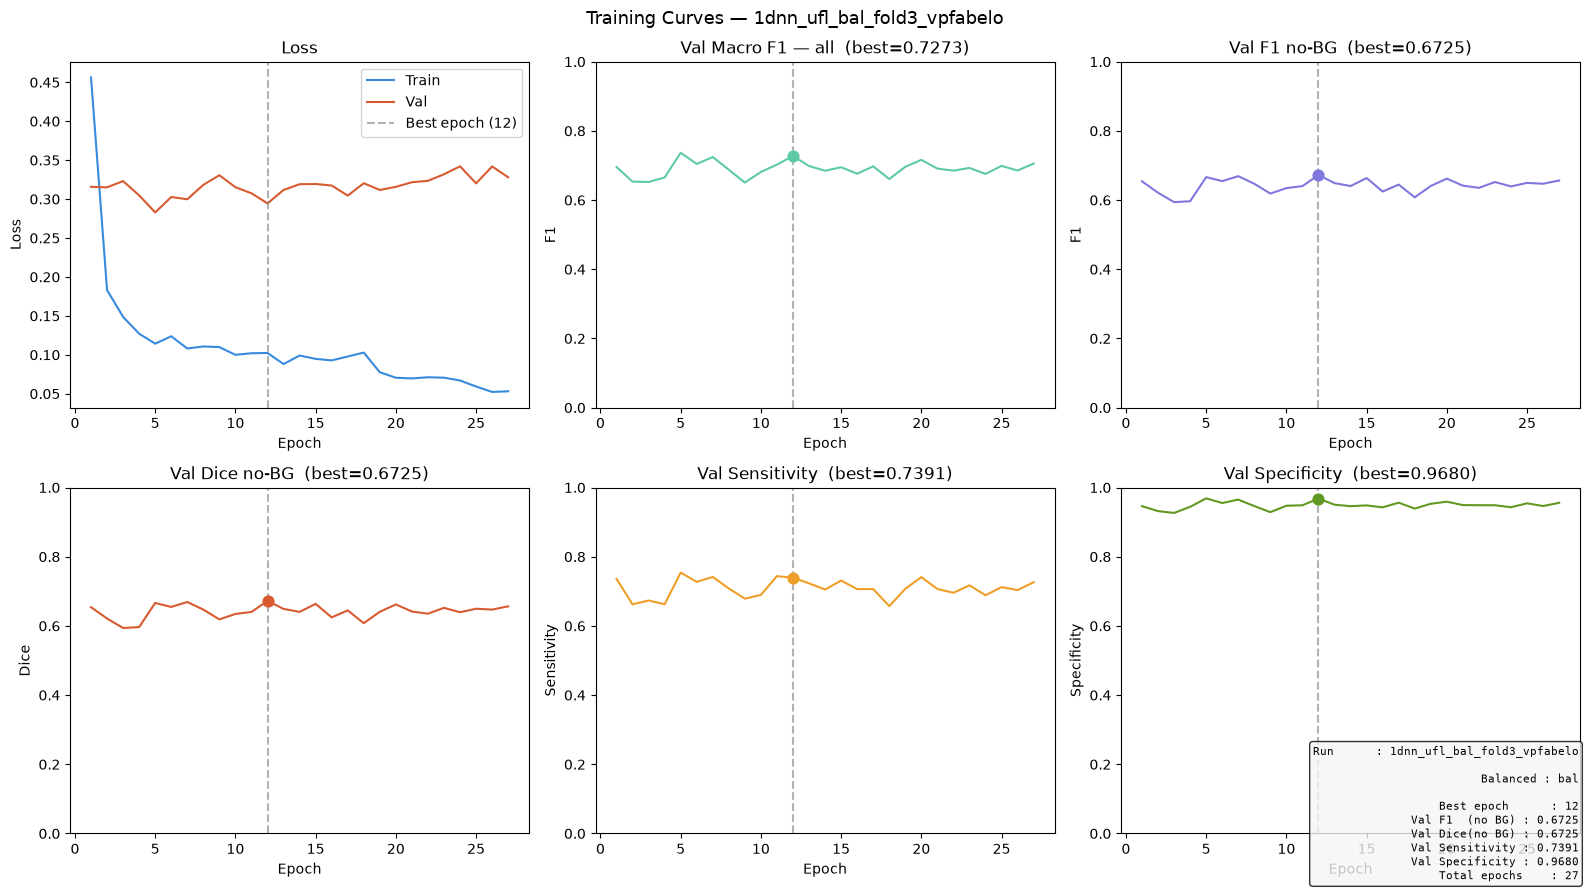

  Saved → ../results/1dnn_ufl_bal_fold3_vpfabelo_curves.png


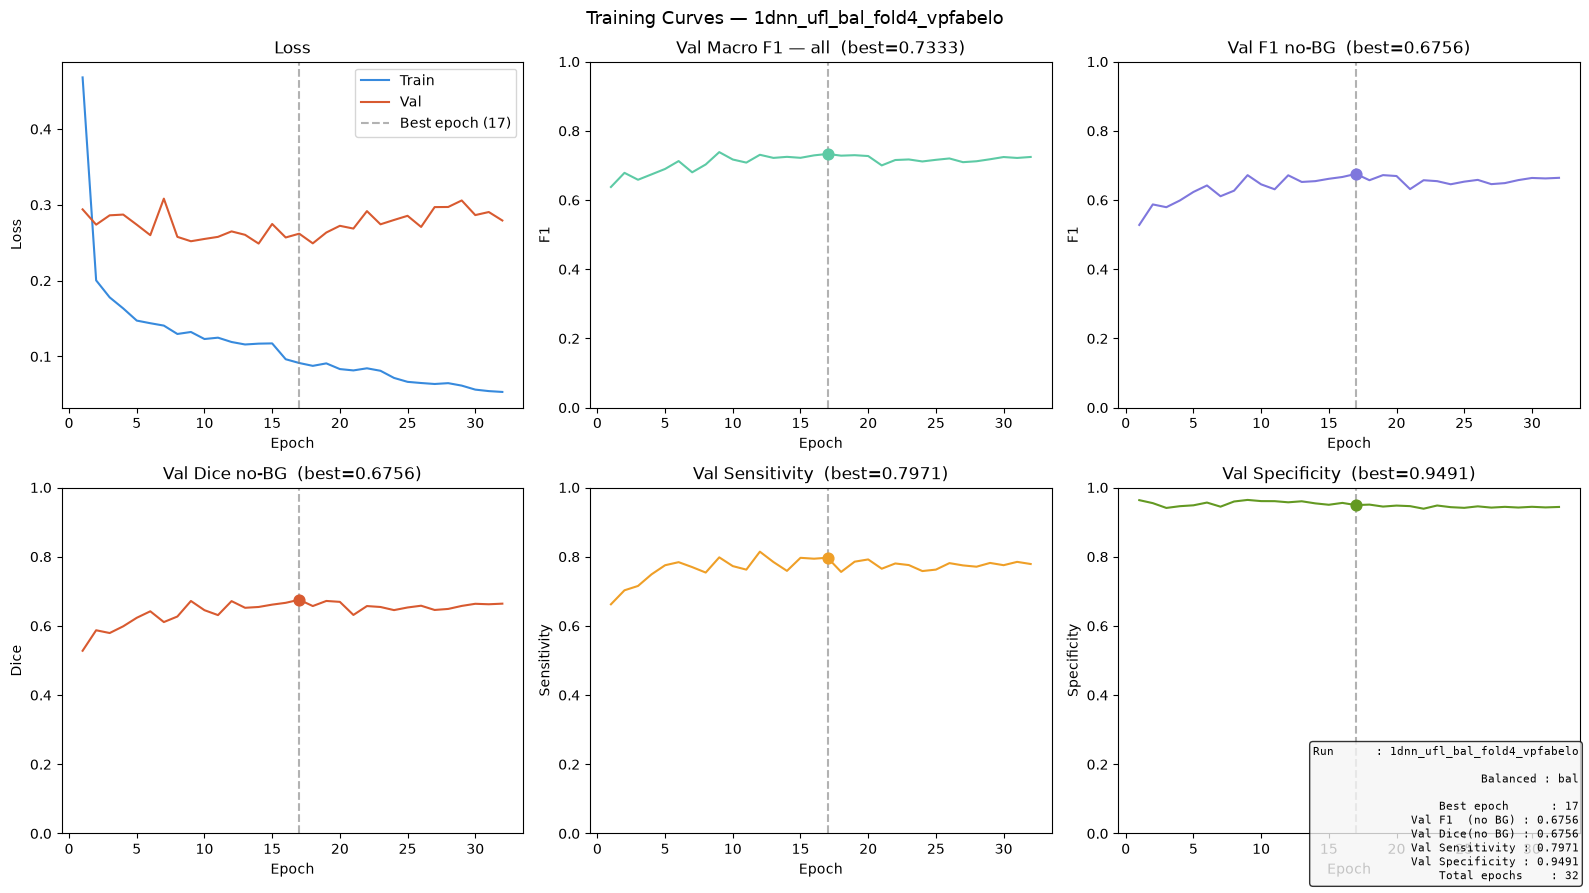

  Saved → ../results/1dnn_ufl_bal_fold4_vpfabelo_curves.png


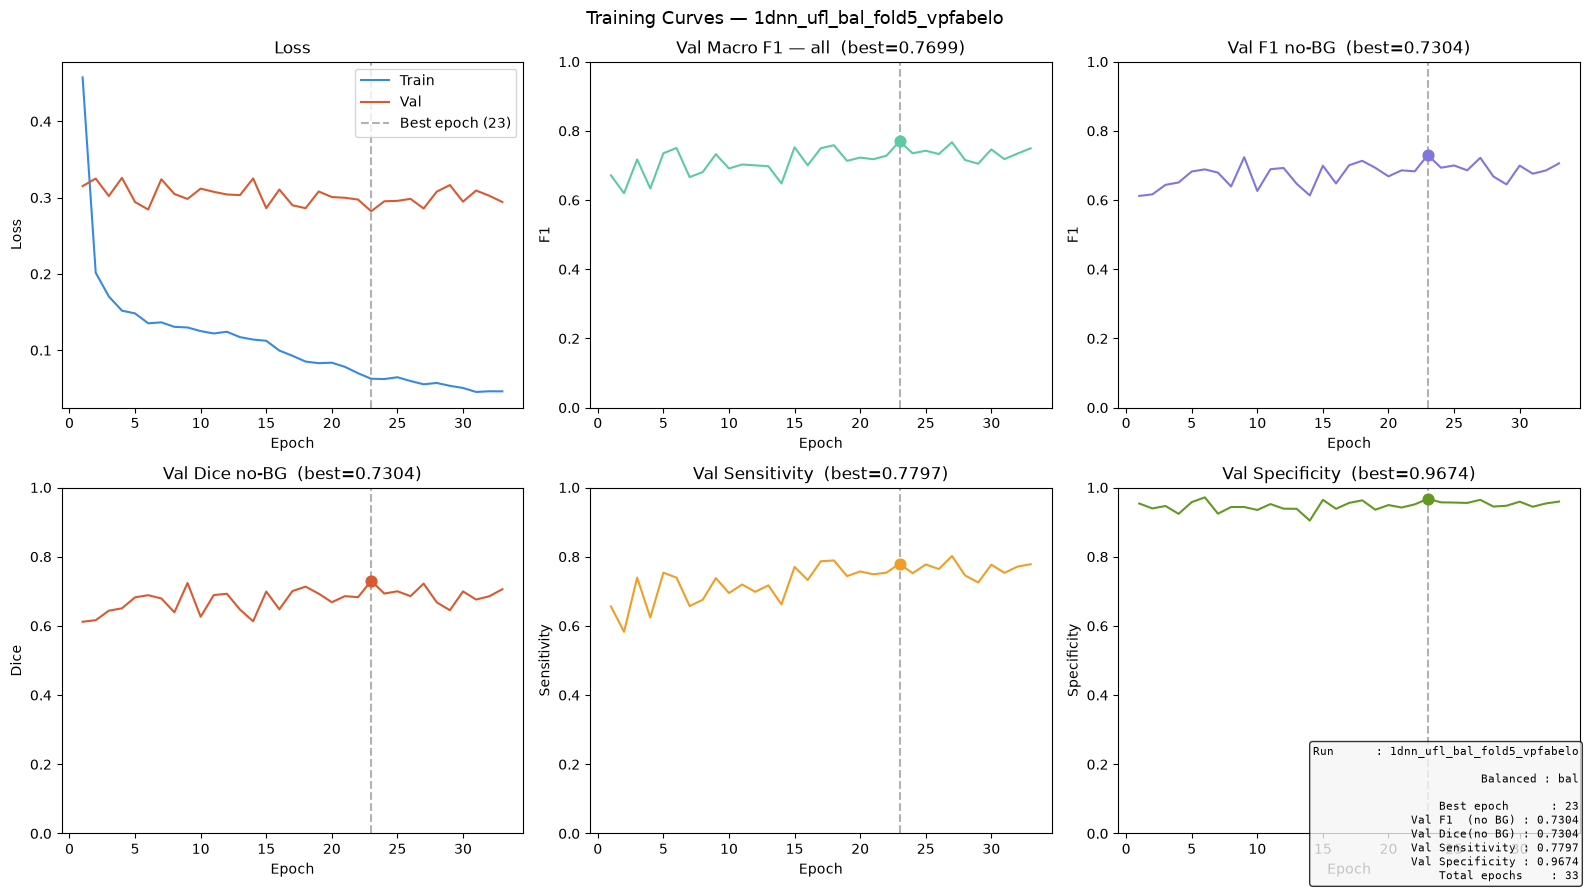

  Saved → ../results/1dnn_ufl_bal_fold5_vpfabelo_curves.png


In [43]:
print(f"\n{'═'*60}")
print(f"  Training Curves — {MODEL} × {LOSS_FN} × {STRATEGY}")
print(f"{'═'*60}")

for split in all_splits:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"]
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
    )
    history  = load_history(cfg, RESULTS_DIR)
    if history:
        plot_history_curves(history, run_name, RESULTS_DIR)

In [44]:
@torch.no_grad()
def predict(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_targets = [], []
    for X, y in loader:
        X      = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
    return np.array(all_preds), np.array(all_targets)


def plot_confusion_matrix(metrics: dict):
    cm   = metrics['confusion_matrix']
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp    = ConfusionMatrixDisplay(
        confusion_matrix = cm_n,
        display_labels   = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f"Confusion Matrix — {metrics['run_name']}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{metrics['run_name']}_cm.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def build_test_loader(split: dict) -> DataLoader:
    """Build test DataLoader — always unbalanced, never augmented."""
    test_patients = split['test']
    if MODEL in PATCH_MODELS:
        test_dataset = HSIPatchDataset(
            test_patients,
            patch_size = PATCH_SIZE,
            balance    = False,
            augment    = False,
        )
    else:
        test_dataset = HSIPixelDataset(test_patients)
    return DataLoader(test_dataset, batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0, pin_memory=True)

In [45]:
def evaluate_fold(split: dict) -> dict | None:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"]
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
    )
    checkpoint_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

    if not checkpoint_path.exists():
        print(f"  ⚠️  Checkpoint not found: {checkpoint_path}")
        return None

    print(f"\n{'─'*60}")
    print(f"  Evaluating : {run_name}")
    if 'val_patient' in split:
        print(f"  Val patient: {split['val_patient']}")
    print(f"  Test images: {len(split['test'])}")
    print(f"{'─'*60}")

    test_loader = build_test_loader(split)

    model = MODEL_REGISTRY[MODEL]().to(device)
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )

    preds, targets = predict(model, test_loader)
    metrics        = compute_metrics(targets, preds, run_name)

    print_metrics(metrics)
    plot_confusion_matrix(metrics)

    print(classification_report(
        targets, preds,
        target_names = [CLASS_NAMES[i+1] for i in range(N_CLASSES)],
        digits=4, zero_division=0
    ))

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    print(f"  Saved → {RESULTS_DIR}/{run_name}_test_metrics.npy")

    del model
    empty_device_cache()

    return metrics


────────────────────────────────────────────────────────────
  Evaluating : 1dnn_ufl_bal_fold1_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ufl_bal_fold1_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7693
  Macro F1  (all classes)    : 0.6941
  Macro F1  (no BG)          : 0.6947  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.6941
  Macro Dice (no BG)         : 0.6947

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8638       0.9383   0.8896   0.8896
  Tumour Tissue (TT)              0.7016       0.8935   0.3964   0.3964  ← clinical priority
  Blood Vessel (BV)               0.9392       0.9149   0.7981   0.7981
  Background (BG)                 0.5689       0.9626   0.6923   0.6923
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7684       0.9273   0.694

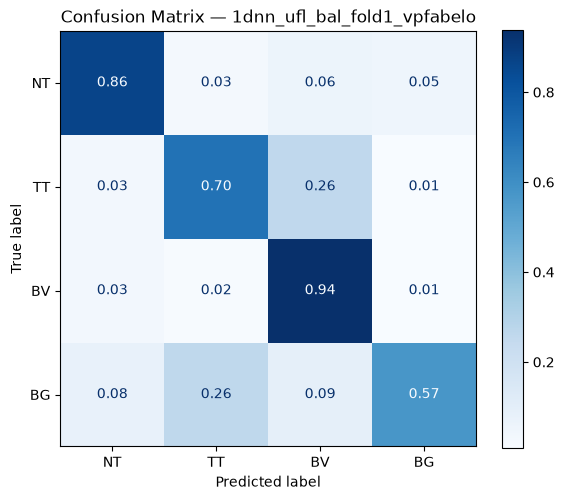

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9169    0.8638    0.8896    108722
Tumour Tissue (TT)     0.2762    0.7016    0.3964     13500
 Blood Vessel (BV)     0.6939    0.9392    0.7981     42005
   Background (BG)     0.8841    0.5689    0.6923     82318

          accuracy                         0.7693    246545
         macro avg     0.6928    0.7684    0.6941    246545
      weighted avg     0.8329    0.7693    0.7811    246545

  Saved → ../results/1dnn_ufl_bal_fold1_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dnn_ufl_bal_fold2_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ufl_bal_fold2_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8202
  Macro F1  (all classes)    : 0.7330
  Macro F1  (no BG)          : 0.7132  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7330
  Macro Dice (no BG)         : 0.7132

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8692       0.9458   0.8970   0.8970
  Tumour Tissue (TT)              0.4576       0.9608   0.4287   0.4287  ← clinical priority
  Blood Vessel (BV)               0.9660       0.9163   0.8139   0.8139
  Background (BG)                 0.7405       0.9355   0.7924   0.7924
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7583       0.9396   0.733

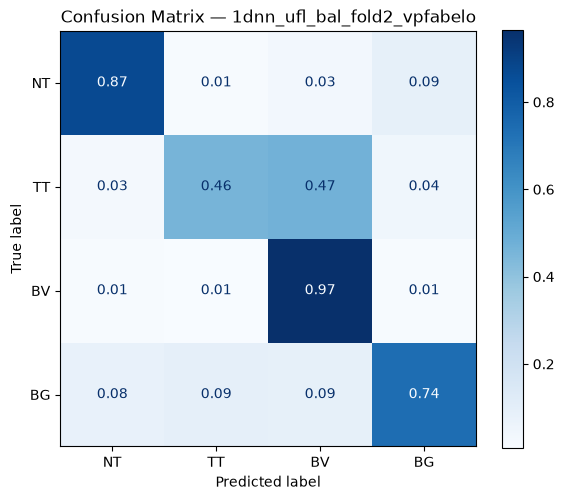

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9267    0.8692    0.8970    108722
Tumour Tissue (TT)     0.4032    0.4576    0.4287     13500
 Blood Vessel (BV)     0.7032    0.9660    0.8139     42005
   Background (BG)     0.8520    0.7405    0.7924     82318

          accuracy                         0.8202    246545
         macro avg     0.7213    0.7583    0.7330    246545
      weighted avg     0.8350    0.8202    0.8223    246545

  Saved → ../results/1dnn_ufl_bal_fold2_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dnn_ufl_bal_fold3_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ufl_bal_fold3_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7965
  Macro F1  (all classes)    : 0.7171
  Macro F1  (no BG)          : 0.7015  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7171
  Macro Dice (no BG)         : 0.7015

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8773       0.9063   0.8790   0.8790
  Tumour Tissue (TT)              0.5474       0.9472   0.4451   0.4451  ← clinical priority
  Blood Vessel (BV)               0.9606       0.8971   0.7804   0.7804
  Background (BG)                 0.6469       0.9763   0.7637   0.7637
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7581       0.9317   0.717

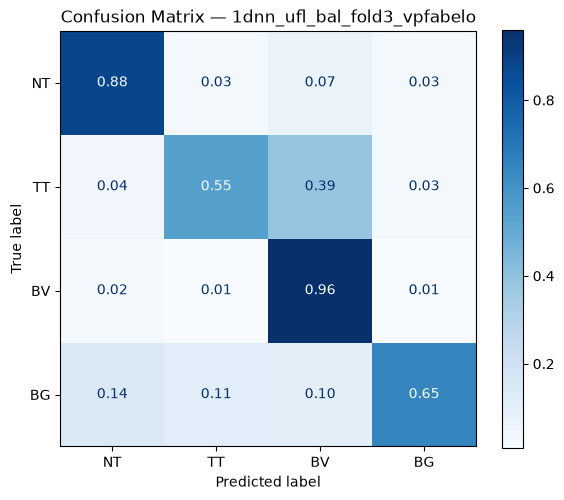

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8807    0.8773    0.8790    108722
Tumour Tissue (TT)     0.3750    0.5474    0.4451     13500
 Blood Vessel (BV)     0.6572    0.9606    0.7804     42005
   Background (BG)     0.9320    0.6469    0.7637     82318

          accuracy                         0.7965    246545
         macro avg     0.7112    0.7581    0.7171    246545
      weighted avg     0.8321    0.7965    0.8000    246545

  Saved → ../results/1dnn_ufl_bal_fold3_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dnn_ufl_bal_fold4_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ufl_bal_fold4_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7959
  Macro F1  (all classes)    : 0.6926
  Macro F1  (no BG)          : 0.6641  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.6926
  Macro Dice (no BG)         : 0.6641

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8676       0.9445   0.8954   0.8954
  Tumour Tissue (TT)              0.3992       0.9433   0.3358   0.3358  ← clinical priority
  Blood Vessel (BV)               0.9287       0.8949   0.7611   0.7611
  Background (BG)                 0.6984       0.9514   0.7780   0.7780
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7235       0.9335   0.692

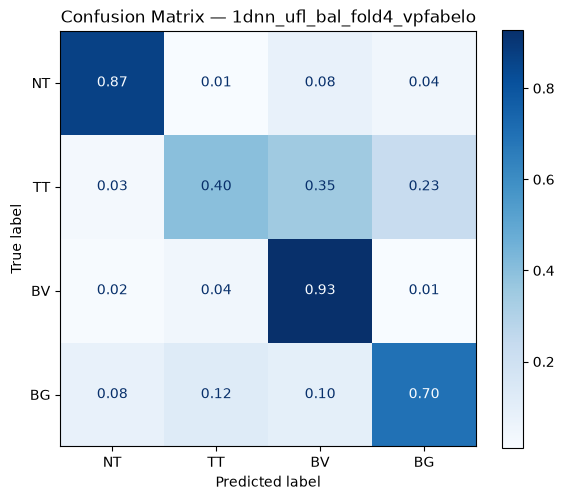

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9250    0.8676    0.8954    108722
Tumour Tissue (TT)     0.2898    0.3992    0.3358     13500
 Blood Vessel (BV)     0.6448    0.9287    0.7611     42005
   Background (BG)     0.8782    0.6984    0.7780     82318

          accuracy                         0.7959    246545
         macro avg     0.6844    0.7235    0.6926    246545
      weighted avg     0.8268    0.7959    0.8027    246545

  Saved → ../results/1dnn_ufl_bal_fold4_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 1dnn_ufl_bal_fold5_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dnn_ufl_bal_fold5_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7837
  Macro F1  (all classes)    : 0.7013
  Macro F1  (no BG)          : 0.6891  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7013
  Macro Dice (no BG)         : 0.6891

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8734       0.9110   0.8794   0.8794
  Tumour Tissue (TT)              0.5261       0.9456   0.4267   0.4267  ← clinical priority
  Blood Vessel (BV)               0.9311       0.8942   0.7612   0.7612
  Background (BG)                 0.6324       0.9591   0.7379   0.7379
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7407       0.9274   0.701

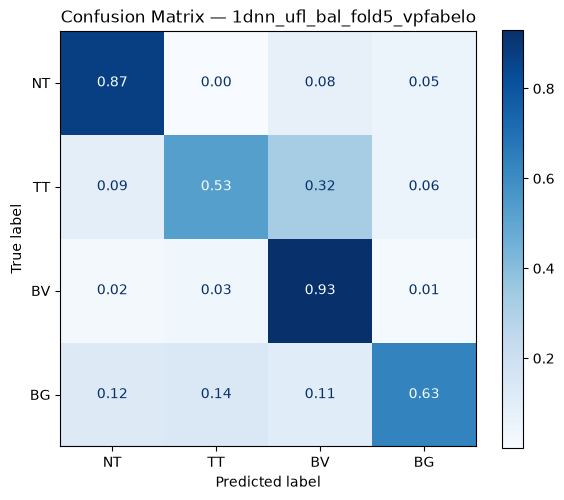

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8855    0.8734    0.8794    108722
Tumour Tissue (TT)     0.3589    0.5261    0.4267     13500
 Blood Vessel (BV)     0.6438    0.9311    0.7612     42005
   Background (BG)     0.8856    0.6324    0.7379     82318

          accuracy                         0.7837    246545
         macro avg     0.6935    0.7407    0.7013    246545
      weighted avg     0.8155    0.7837    0.7872    246545

  Saved → ../results/1dnn_ufl_bal_fold5_vpfabelo_test_metrics.npy


In [46]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

all_metrics = []
for split in all_splits:
    metrics = evaluate_fold(split)
    if metrics:
        all_metrics.append(metrics)

In [47]:
aggregate = aggregate_fold_metrics(all_metrics)

In [48]:
print_aggregate(aggregate, model=MODEL, loss_fn=LOSS_FN, strategy=STRATEGY)


═════════════════════════════════════════════════════════════════
  AGGREGATE — 1D-NN × UFL × vp_fabelo
  5 folds
═════════════════════════════════════════════════════════════════
  Macro F1  (all)    : 70.1 ± 1.5%
  Macro F1  (no BG)  : 69.5 ± 1.6%  ← vs Fabelo 70.2 ± 7.9%
  Macro Dice (all)   : 70.1 ± 1.5%
  Macro Dice (no BG) : 69.5 ± 1.6%
  OA                 : 79.6 ± 1.7%

  Class      Sens     ±     Spec     ±      Dice     ±
  ───────────────────────────────────────────────────────
  NT        86.9%   ± 0.5%     93.8%   ± 1.7%     89.0%   ± 0.8%
  TT        52.6%   ±10.2%     94.6%   ± 2.3%     42.7%   ± 3.9%  ← clinical priority
  BV        93.9%   ± 1.5%     89.7%   ± 1.0%     78.0%   ± 2.1%
  BG        64.7%   ± 5.9%     95.9%   ± 1.3%     76.4%   ± 3.5%

  Per-fold F1 (no BG)  : ['69.5%', '71.3%', '70.2%', '66.4%', '68.9%']
  Per-fold Dice (no BG): ['69.5%', '71.3%', '70.2%', '66.4%', '68.9%']
